## Nu-SVM (NuSVC) — Implémentation complète avec sklearn
# Dataset : Breast Cancer Wisconsin

In [1]:
# IMPORTS

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.svm import NuSVC, SVC
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

In [2]:
#  CHARGEMENT ET PRÉPARATION DES DONNÉES

print("=" * 60)
print("  NU-SVM — Breast Cancer Wisconsin")
print("=" * 60)

data = load_breast_cancer()
X, y = data.data, data.target
feature_names = data.feature_names
class_names = data.target_names  # ['malignant', 'benign']

print(f"\n[Dataset]")
print(f"  Samples     : {X.shape[0]}")
print(f"  Features    : {X.shape[1]}")
print(f"  Classes     : {class_names} → {np.bincount(y)}")

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalisation — indispensable pour SVM
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

  NU-SVM — Breast Cancer Wisconsin

[Dataset]
  Samples     : 569
  Features    : 30
  Classes     : ['malignant' 'benign'] → [212 357]


In [ ]:

# ENTRAÎNEMENT DU MODÈLE NU-SVC
nu_model = NuSVC(nu=0.1, kernel='rbf', gamma='scale', probability=True, random_state=42)
nu_model.fit(X_train_sc, y_train)

y_pred      = nu_model.predict(X_test_sc)
y_proba     = nu_model.predict_proba(X_test_sc)[:, 1]
train_score = nu_model.score(X_train_sc, y_train)
test_score  = nu_model.score(X_test_sc, y_test)

print(f"  Accuracy (train) : {train_score:.4f}")
print(f"  Accuracy (test)  : {test_score:.4f}")
print(f"  Support vectors  : {nu_model.n_support_} → total {sum(nu_model.n_support_)}")
print(f"\n[Rapport de classification]")
print(classification_report(y_test, y_pred, target_names=class_names))



[Entraînement NuSVC — nu=0.1, kernel=rbf]
  Accuracy (train) : 0.9868
  Accuracy (test)  : 0.9737
  Support vectors  : [45 39] → total 84

[Rapport de classification]
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [ ]:
# CROSS-VALIDATION
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(nu_model, X_train_sc, y_train, cv=cv, scoring='accuracy')
print(f"  Scores : {cv_scores.round(4)}")
print(f"  Moyenne ± std : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

[Cross-validation — StratifiedKFold k=5]
  Scores : [0.9451 0.978  0.956  0.967  0.989 ]
  Moyenne ± std : 0.9670 ± 0.0155


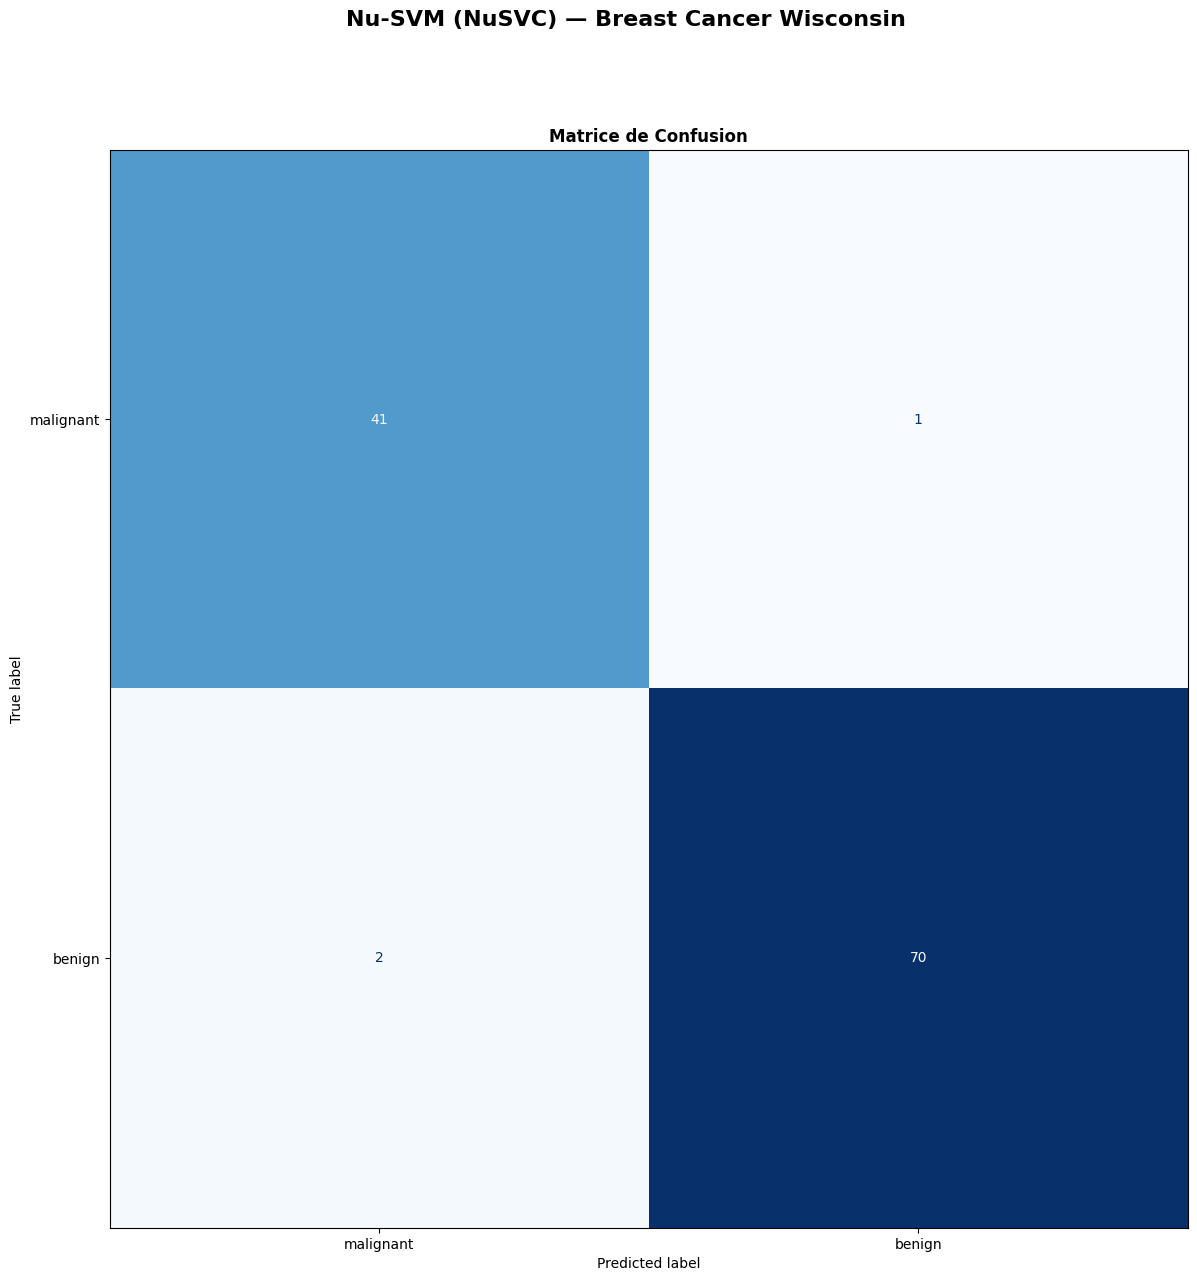

In [9]:

# VISUALISATIONS
fig = plt.figure(figsize=(18, 14))
fig.suptitle("Nu-SVM (NuSVC) — Breast Cancer Wisconsin", fontsize=16, fontweight='bold', y=0.98)



# Matrice de confusion 
ax1 = fig.add_subplot(1, 1, 1)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title("Matrice de Confusion", fontweight='bold');

